In [57]:
import os
from zipfile import ZipFile
from pathlib import Path
import requests

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.family"] = "DejaVu Sans"

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [58]:
def load_har_dataset(url, extract_path: Path, filename: str, overwrite=False):
    extract_path.mkdir(parents=True, exist_ok=True)
    filepath = extract_path / filename
    if filepath.exists() and not overwrite:
        print("The dataset is already in place.")
        return

    print("Downloading the dataset from:  ", url)
    response = requests.get(url)
    response.raise_for_status()

    with open(filepath, 'wb') as f:
        f.write(response.content)

    with ZipFile(filepath, 'r') as zipObj:
        # Extract all the contents of zip file in current directory
        zipObj.extractall(extract_path)

In [59]:
FILE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
FILE_NAME = "UCI HAR Dataset.zip"
DATA_PATH = Path("../data/large_files")

load_har_dataset(url=FILE_URL, extract_path=DATA_PATH, filename=FILE_NAME)

PATH_TO_SAMSUNG_DATA = DATA_PATH / FILE_NAME.strip('.zip')

The dataset is already in place.


In [60]:
X_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "X_train.txt")
y_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "y_train.txt").astype(int)

X_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "X_test.txt")
y_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "y_test.txt").astype(int)

In [61]:
# Checking dimensions
assert X_train.shape == (7352, 561) and y_train.shape == (7352,)
assert X_test.shape == (2947, 561) and y_test.shape == (2947,)

In [62]:
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

define number of unique values of the labels of the target class

In [63]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [ ]:
n_classes = np.unique(y).size

scale the sample using StyandardScaler with default parameters

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reduce the number of dimensions using PCA, lçeaving as many components as necessary to explain at least 90% of the variance of the original (scaled) data. Use the scaled dataset and fix random_state

In [66]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE).fit(X_scaled)
X_pca = pca.transform(X_scaled)

Q1: What is the minimum number of principal componentes required to cover the 90% of the variance of the original (scaled) data

In [67]:
X_pca.shape

(10299, 65)

Q2: What percentage of the varience is covered by the first principal component? Round to the nearest percent

In [68]:
round(pca.explained_variance_ratio_[0] * 100)

51

Visualize data in projection on the first two principal components.

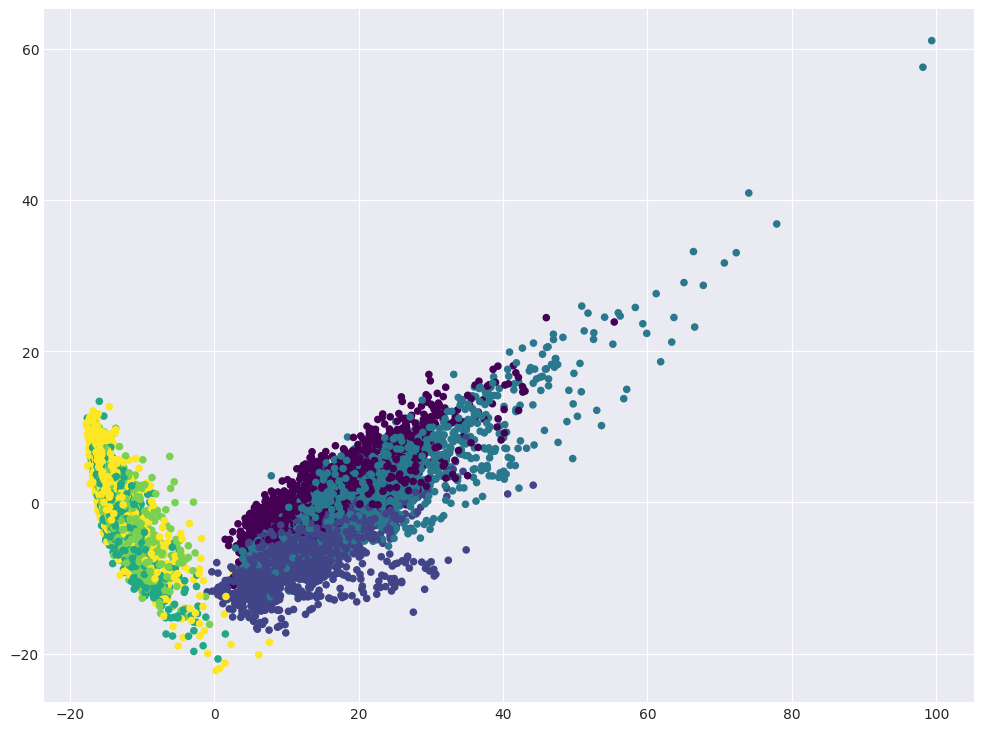

In [69]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap="viridis");

Q3: If everything worked out correctly, you will see a number of clusters, almost perfectly separated from each other. What types of activity are included in these clusters?

In [70]:
kmeans = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
kmeans.fit(X_pca)
cluster_labels = kmeans.labels_

Visualize data in projection on the first two principal components. Color the dots according to the clusters obtained

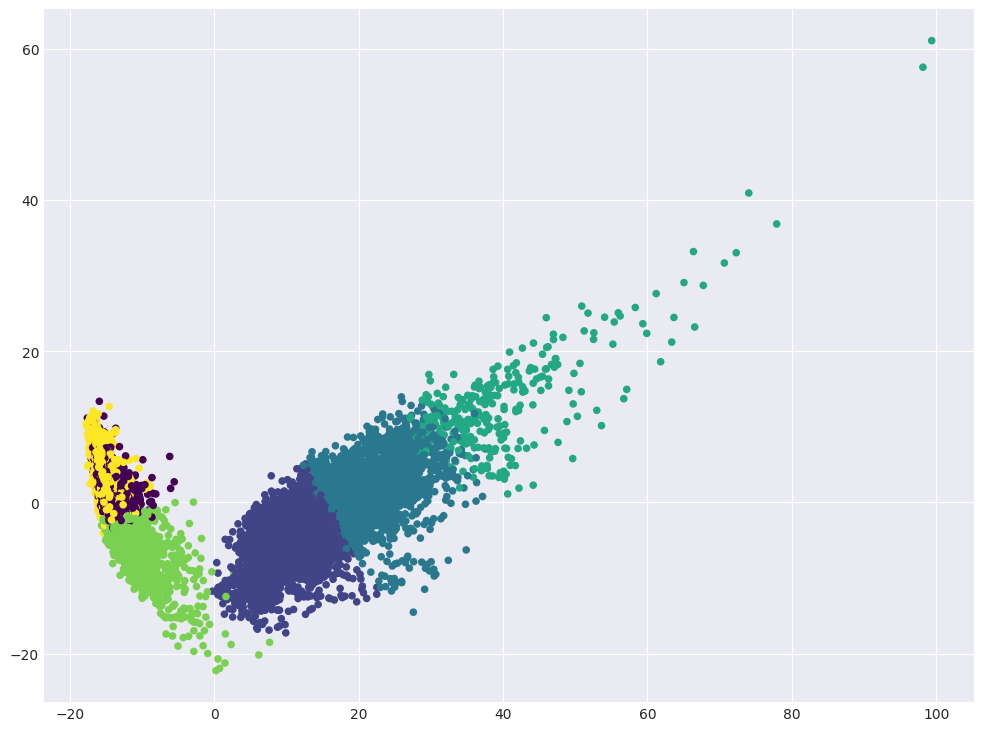

In [71]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=20, cmap="viridis");

Look at the correspondence between the cluster marks and the original class labels and what kinds of activities the KMeans algorithm is confused at

In [72]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = [
    "walking",
    "going up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab.columns = ["cluster" + str(i + 1) for i in range(6)] + ["all"]
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,all
walking,0,903,741,78,0,0,1722
going up the stairs,0,1241,296,5,2,0,1544
going down the stairs,0,320,890,196,0,0,1406
sitting,1235,1,0,0,450,91,1777
standing,1344,0,0,0,562,0,1906
laying,52,5,0,0,329,1558,1944
all,2631,2470,1927,279,1343,1649,10299


Q4: Which activity is separated from the rest better than others based on the simple metric described above?

In [73]:
pd.Series(
    tab.iloc[:-1, :-1].max(axis=1).values / tab.iloc[:-1, -1].values,
    index=tab.index[:-1],
)

walking                  0.524390
going up the stairs      0.803756
going down the stairs    0.633001
sitting                  0.694992
standing                 0.705142
laying                   0.801440
dtype: float64

In [74]:
inertia = []
for k in tqdm(range(1, n_classes + 1)):
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE).fit(
        X_pca
    )
    inertia.append(np.sqrt(kmeans.inertia_))

  0%|          | 0/6 [00:00<?, ?it/s]

Train `LinearSVC` on PCA-reduced data. Tune `C` with `GridSearchCV` (3-fold CV). Save the best model as `best_svc`.

In [75]:
svc_grid = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE),
    param_grid={"C": np.logspace(-3, 2, 10)},
    cv=3,
    n_jobs=-1,
)
svc_grid.fit(X_pca, y)
best_svc = svc_grid.best_estimator_
svc_grid.best_params_

{'C': np.float64(7.742636826811277)}

Which activity type is worst detected by SVM in terms of precision?

In [76]:
activity_labels = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}

y_pred = best_svc.predict(X_pca)
report = metrics.classification_report(y, y_pred, output_dict=True)

precision_by_activity = pd.Series(
    {activity_labels[int(float(label))]: report[str(int(float(label)))]["precision"]
     for label in np.unique(y)},
)

precision_by_activity.sort_values()

SITTING               0.905949
STANDING              0.908142
WALKING_UPSTAIRS      0.981181
WALKING_DOWNSTAIRS    0.984353
WALKING               0.989571
LAYING                0.999486
dtype: float64

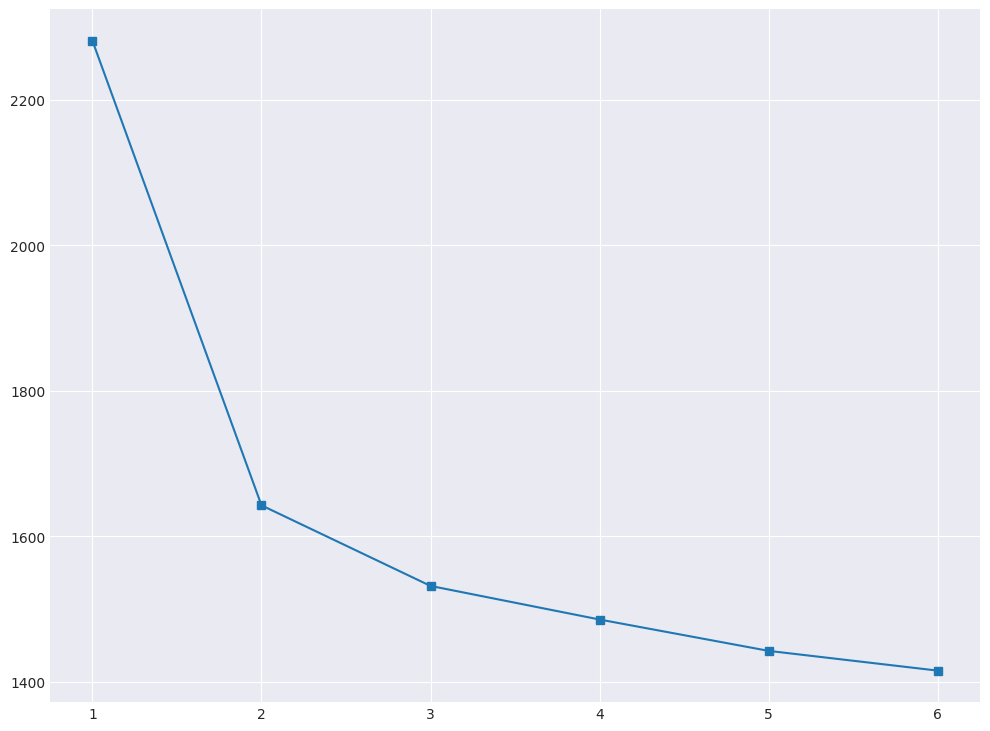

In [77]:
plt.plot(range(1, 7), inertia, marker="s");

In [78]:
d = {}
for k in range(2, 6):
    i = k - 1
    d[k] = (inertia[i] - inertia[i + 1]) / (inertia[i - 1] - inertia[i])

In [79]:
d

{2: np.float64(0.17344753560094248),
 3: np.float64(0.4168855575586454),
 4: np.float64(0.933219890974876),
 5: np.float64(0.6297014287707485)}

Q5: How many clusters can we chose according to the elbow method

In [80]:
ag = AgglomerativeClustering(n_clusters=n_classes, linkage="ward").fit(X_pca)

Calculate the Adjusted Rand Index sklern.metrics forthe resulting clustering and for KMeans with the parameters for the 4th question

In [81]:
print("KMeans: ARI =", metrics.adjusted_rand_score(y, cluster_labels))
print("Agglomerative CLustering: ARI =", metrics.adjusted_rand_score(y, ag.labels_))

KMeans: ARI = 0.4198070012602345
Agglomerative CLustering: ARI = 0.49362763373004886


Q6: Train the new StandardScaler on the training set (with all original features), apply scaling to the test set. In GrinSearchCV, specify CV=3

In [82]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}


In [84]:
%%time
best_svc = GridSearchCV(svc, svc_params, n_jobs=4, cv=3, verbose=1)
best_svc.fit(X_train_scaled, y_train);

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CPU times: user 12.2 s, sys: 712 ms, total: 12.9 s
Wall time: 2min 38s


In [85]:
best_svc.best_params_, best_svc.best_score_

({'C': 0.1}, np.float64(0.9379785010699506))

Q7: Which value of the hyperparameter C was chosen the best on the basis of cross-validation

In [86]:
y_predicted = best_svc.predict(X_test_scaled)

In [87]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab.columns = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab

,walking,climbing up the stairs,going down the stairs,sitting,standing,laying,all
walking,494,2,0,0,0,0,496
climbing up the stairs,12,459,0,0,0,0,471
going down the stairs,2,4,413,1,0,0,420
sitting,0,4,0,426,61,0,491
standing,0,0,0,15,517,0,532
laying,0,0,0,0,11,526,537
all,508,469,413,442,589,526,2947


Q8: Which activity type is worst detected by SVM in terms of precision

In [88]:
y_predicted = best_svc.predict(X_test_scaled)
y_predicted = best_svc.predict(X_train_scaled)

In [89]:
tab = pd.crosstab(y_train, y_predicted, margins=True)
tab.index = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab.columns = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab

,walking,climbing up the stairs,going down the stairs,sitting,standing,laying,all
walking,1226,0,0,0,0,0,1226
climbing up the stairs,0,1073,0,0,0,0,1073
going down the stairs,0,0,986,0,0,0,986
sitting,0,0,0,1266,20,0,1286
standing,0,0,0,20,1354,0,1374
laying,0,0,0,0,0,1407,1407
all,1226,1073,986,1286,1374,1407,7352


Q9: What is the difference between the best quality (accuracy) for cross-validation in the case of all 561 initial characteristics and in the second case, when the principal component method was applied? Round to the nearest percent.

In [90]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [91]:
svc = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

In [92]:
%%time
best_svc_pca = GridSearchCV(svc, svc_params, n_jobs=4, cv=3, verbose=1)
best_svc_pca.fit(X_train_pca, y_train);

Fitting 3 folds for each of 5 candidates, totalling 15 fits
CPU times: user 1.23 s, sys: 105 ms, total: 1.34 s
Wall time: 10.8 s


In [93]:
best_svc_pca.best_params_, best_svc_pca.best_score_

({'C': 0.1}, np.float64(0.8983982658750974))

In [94]:
round(100 * (best_svc_pca.best_score_ - best_svc.best_score_))

-4